# Lab 9 — Variant 6

**Part A:** Real-Time ECG Signal Processing — `fs = 250 Hz`, `duration = 12 s`, `block = 125 samples`.

**Part B:** Kalman-Bucy filter for $\dot{x} = -1.2\,x + w$, $y = x + v$, with $Q = 0.3$, $R = 1.2$.

## Part A — Real-Time-like ECG Processing

Real-time-like ECG filtering: fs=250 Hz, block=125 samples, block duration=0.500 s, blocks=24


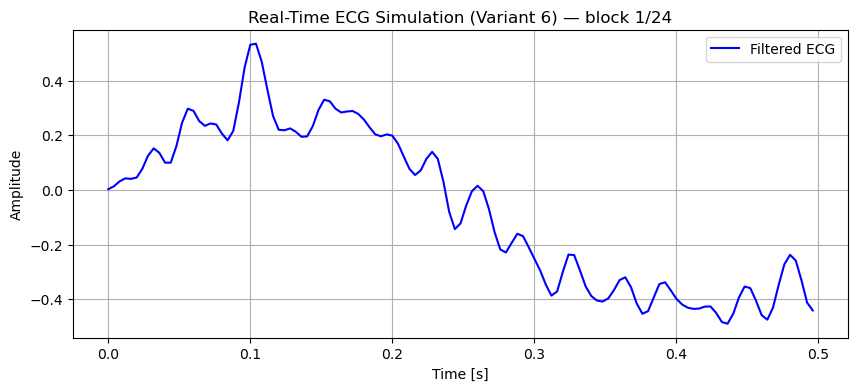

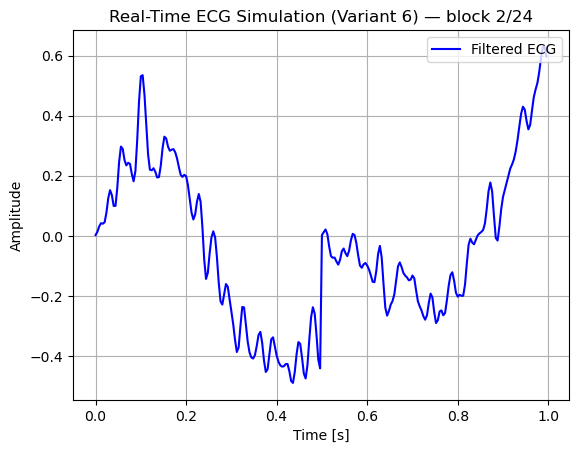

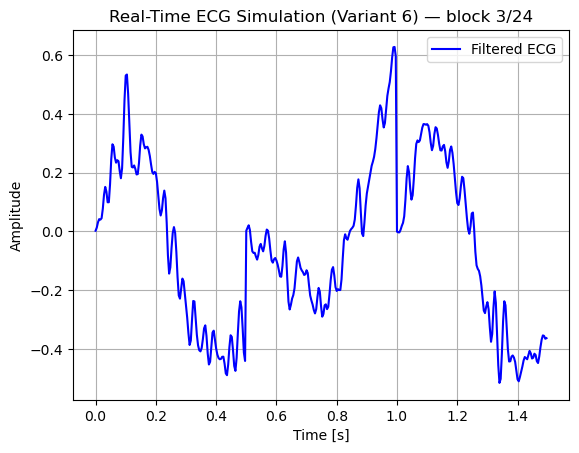

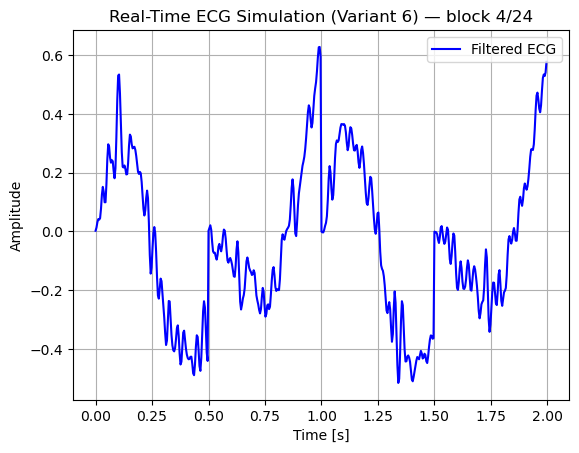

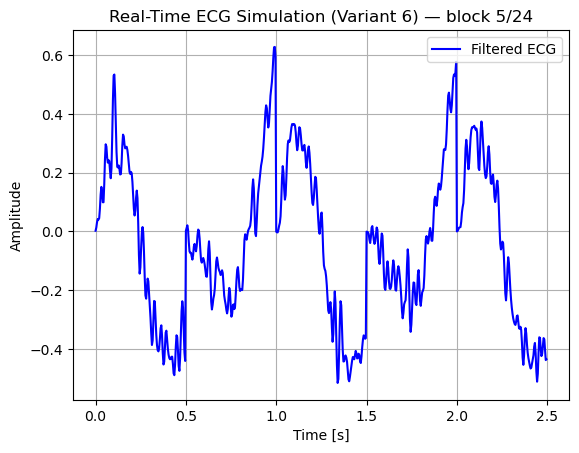

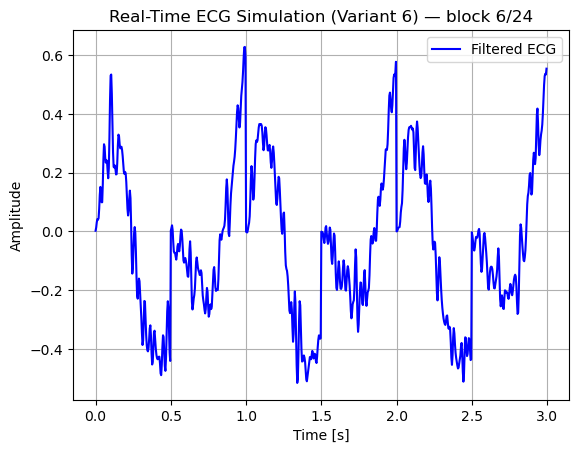

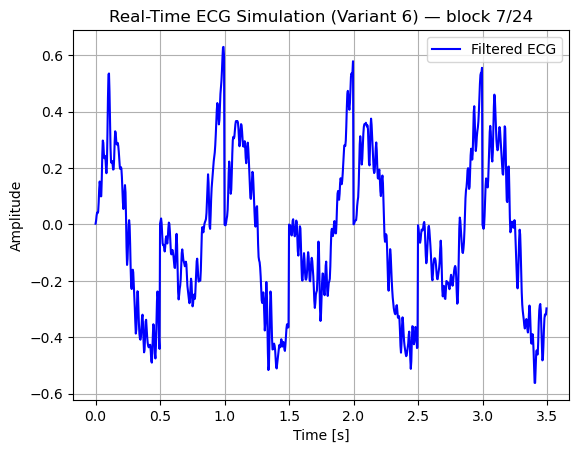

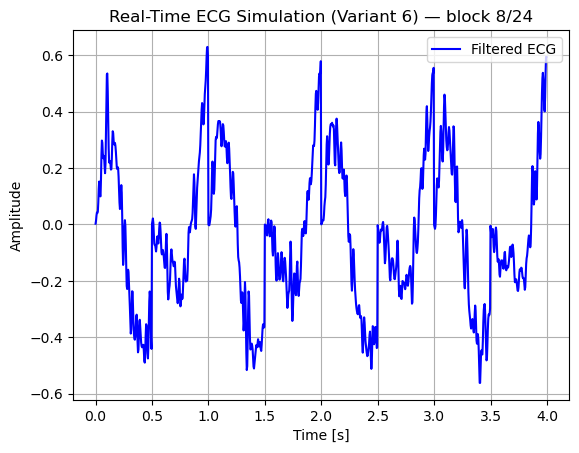

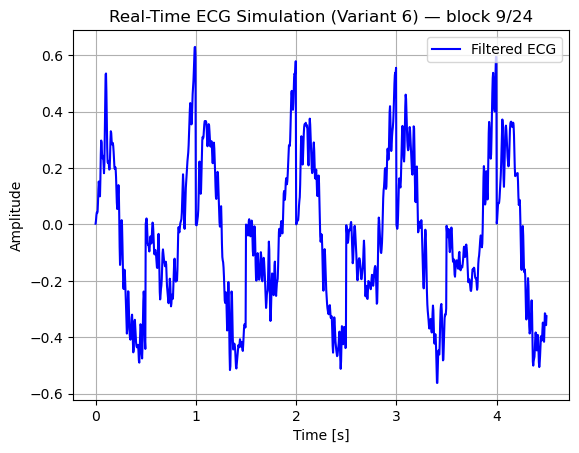

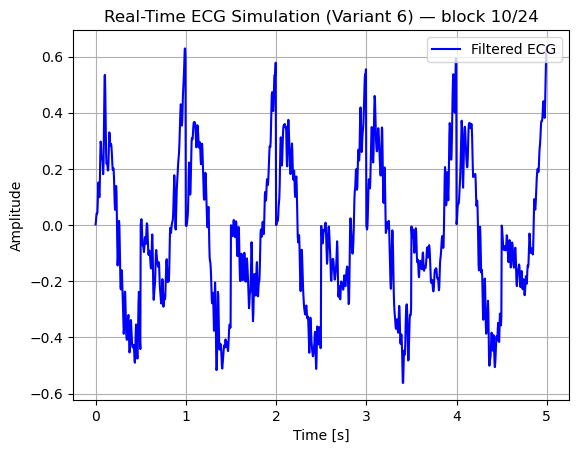

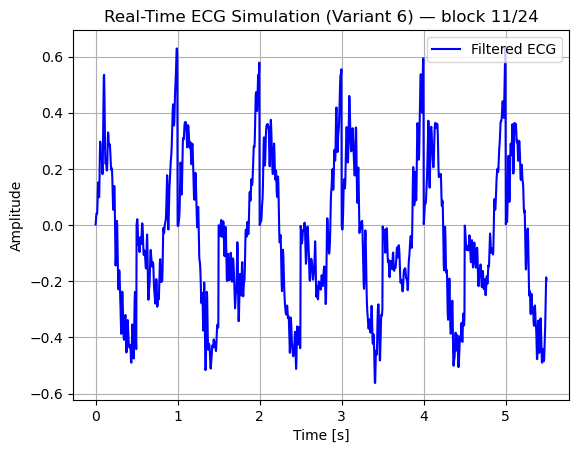

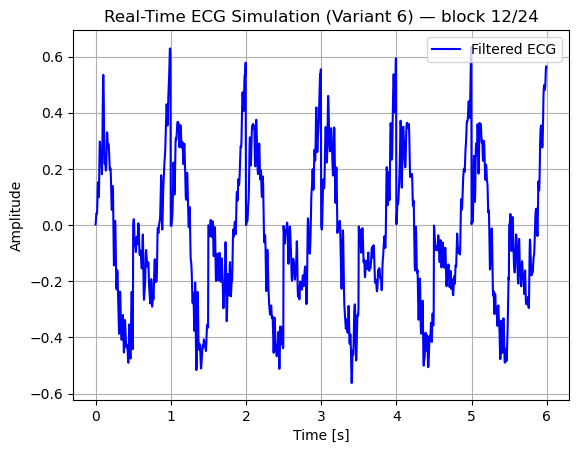

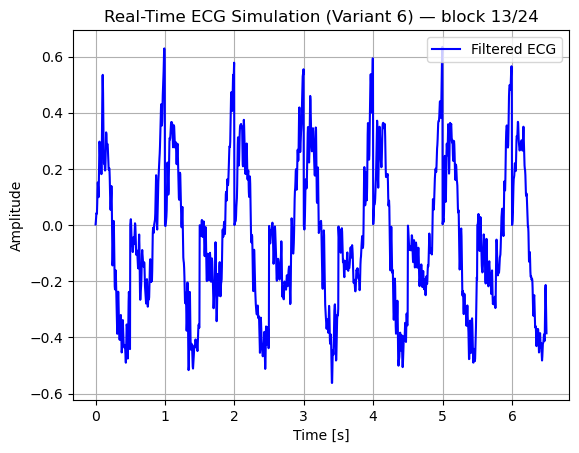

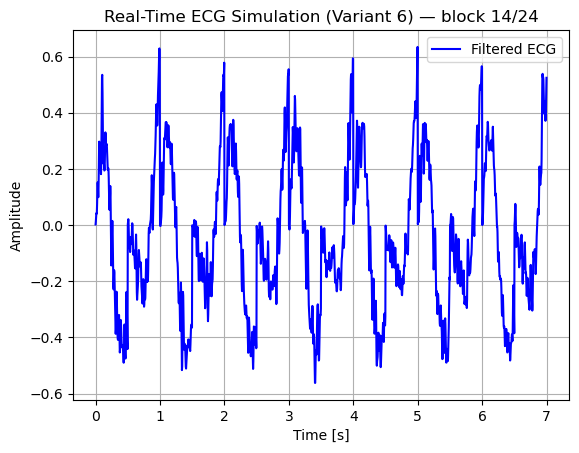

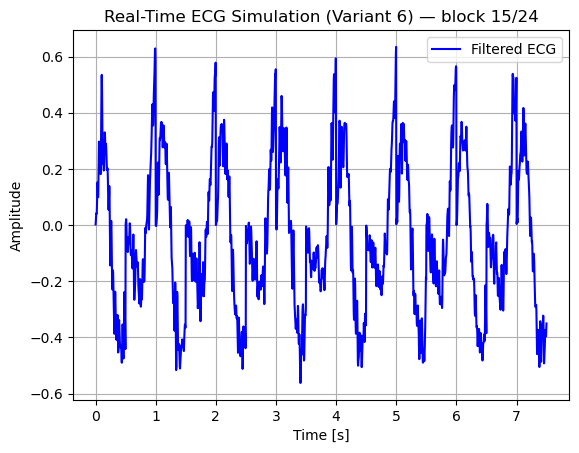

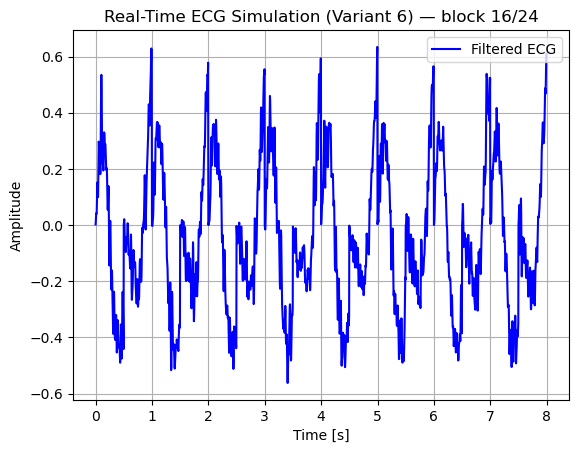

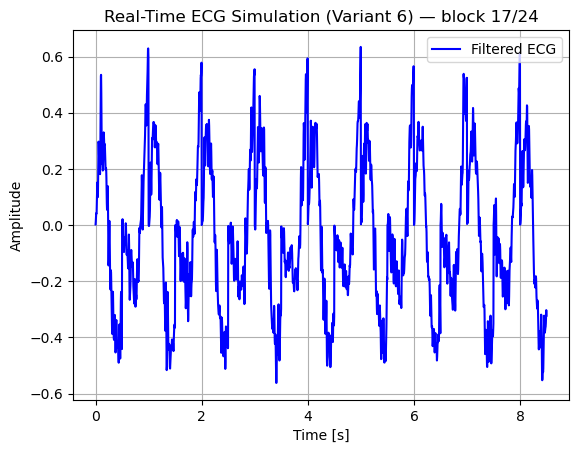

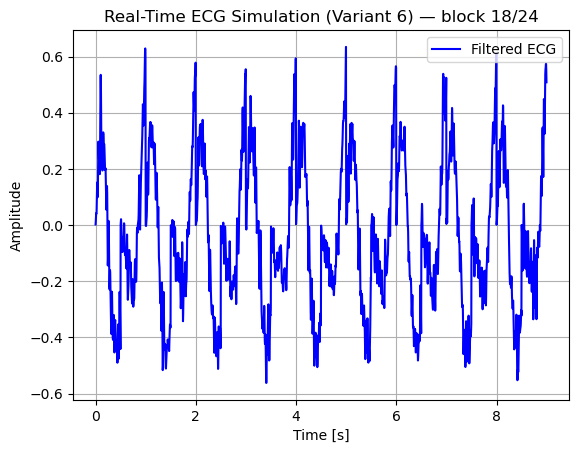

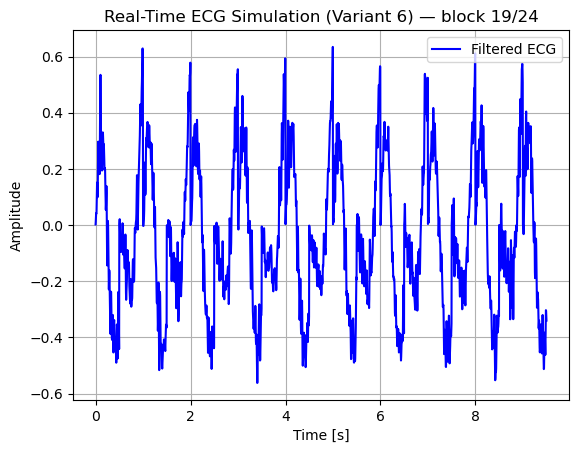

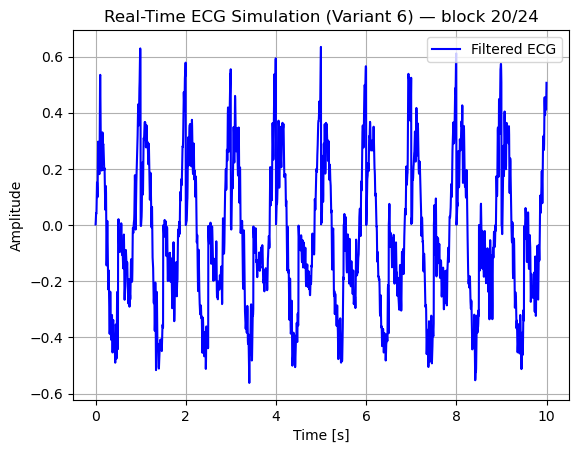

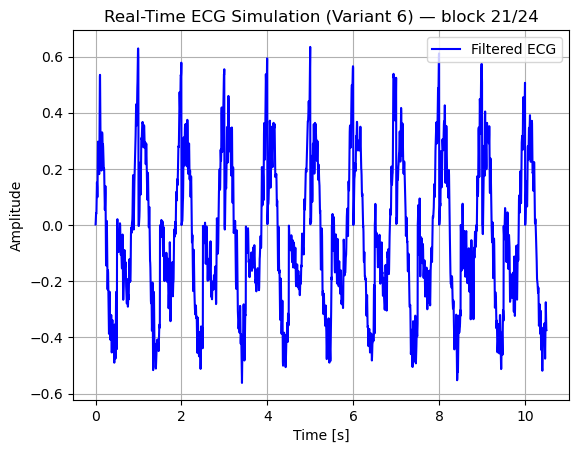

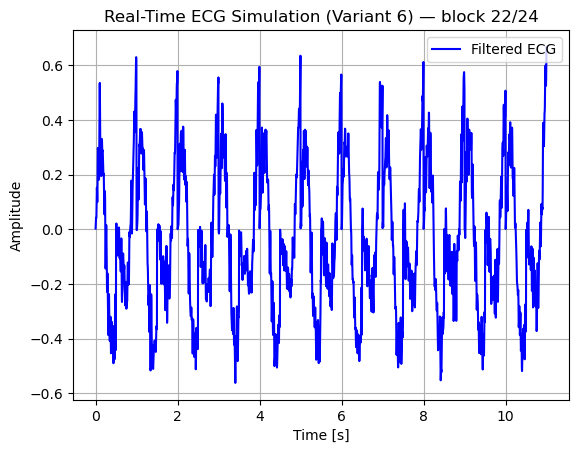

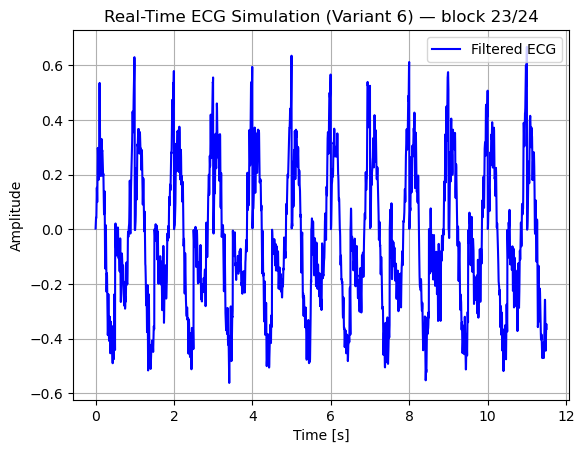

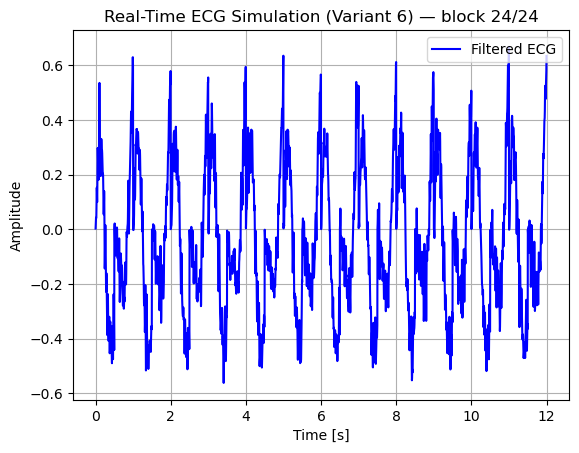

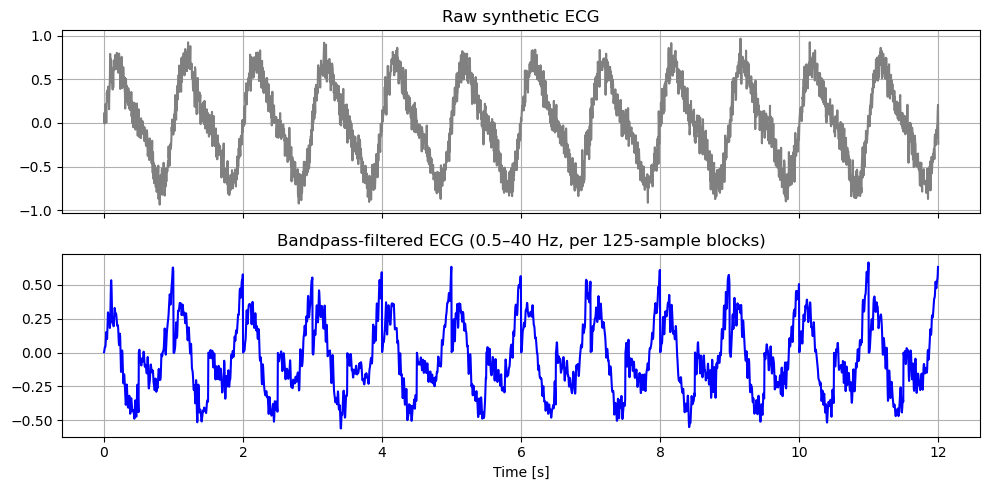

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.signal import butter, lfilter

# --- 1. Synthetic ECG-like signal ---
def synthetic_ecg(fs, duration, heart_rate=60):
    t = np.linspace(0, duration, int(fs * duration))
    ecg = (0.6 * np.sin(2 * np.pi * heart_rate/60 * t)
           + 0.2 * np.sin(2 * np.pi * 2 * heart_rate/60 * t)
           + 0.1 * np.random.randn(len(t)))
    return t, ecg

# --- 2. Bandpass filter (0.5–40 Hz) ---
def bandpass_filter(signal, fs, lowcut=0.5, highcut=40.0, order=4):
    nyq = 0.5 * fs
    low, high = lowcut / nyq, highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return lfilter(b, a, signal)

# --- 3. Simulate real-time block processing ---
def simulate_real_time_processing(ecg_signal, fs, block_size):
    total_samples = len(ecg_signal)
    num_blocks = total_samples // block_size
    delay = block_size / fs  # seconds per block (== 0.5 s for Variant 6)

    processed_signal = []
    t_axis = []

    print(f"Real-time-like ECG filtering: fs={fs} Hz, block={block_size} samples, "
          f"block duration={delay:.3f} s, blocks={num_blocks}")

    plt.figure(figsize=(10, 4))
    for i in range(num_blocks):
        block = ecg_signal[i*block_size:(i+1)*block_size]
        filtered = bandpass_filter(block, fs)
        processed_signal.extend(filtered)
        t_axis.extend(np.arange(i*block_size, (i+1)*block_size) / fs)

        plt.clf()
        plt.plot(t_axis, processed_signal, color='blue', label='Filtered ECG')
        plt.xlabel('Time [s]')
        plt.ylabel('Amplitude')
        plt.title(f'Real-Time ECG Simulation (Variant 6) — block {i+1}/{num_blocks}')
        plt.grid(True)
        plt.legend(loc='upper right')
        plt.pause(0.01)
        time.sleep(delay)
    plt.show()

    return np.array(t_axis), np.array(processed_signal)

# --- Run simulation (Variant 6) ---
fs = 250           # Hz
duration = 12      # s
block_size = 125   # samples (0.5 s per block)

t, ecg = synthetic_ecg(fs, duration)
t_proc, ecg_proc = simulate_real_time_processing(ecg, fs, block_size=block_size)

# --- Comparison: raw vs filtered ---
fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
ax[0].plot(t, ecg, color='gray'); ax[0].set_title('Raw synthetic ECG'); ax[0].grid(True)
ax[1].plot(t_proc, ecg_proc, color='blue'); ax[1].set_title('Bandpass-filtered ECG (0.5–40 Hz, per 125-sample blocks)')
ax[1].set_xlabel('Time [s]'); ax[1].grid(True)
plt.tight_layout(); plt.show()

### Part A — Interpretation

- With `fs = 250 Hz` and `block = 125 samples`, every block spans **0.5 s** of signal. Processing in blocks emulates a real-time stream: the filter works only on data already acquired, and the `time.sleep(0.5)` between blocks mimics the acquisition pace.
- The Butterworth bandpass (0.5–40 Hz) removes low-frequency baseline drift and high-frequency noise above the ECG band while keeping the dominant cardiac components (~1 Hz fundamental + harmonics).
- Because `lfilter` is applied per-block without state carry-over, short transients appear at block boundaries. In a true real-time implementation the filter state (`zi`) should be preserved between calls to eliminate these seams.
- Variant 6 uses a shorter block than the lab default (125 vs 250 samples), giving lower latency (0.5 s) at the cost of more visible block-boundary transients.

## Part B — Kalman-Bucy Filter (scalar)

System: $\dot{x} = A\,x + w$, $y = C\,x + v$ with $A = -1.2$, $C = 1$, $Q = 0.3$, $R = 1.2$.

Continuous Riccati: $\dot{P} = 2AP + Q - \dfrac{P^2 C^2}{R}$; gain $K = PC/R$.

Steady-state P = 0.1200, K = 0.1000
Numerical    P(T) = 0.1200, K(T) = 0.1000
Estimation RMSE = 0.3930


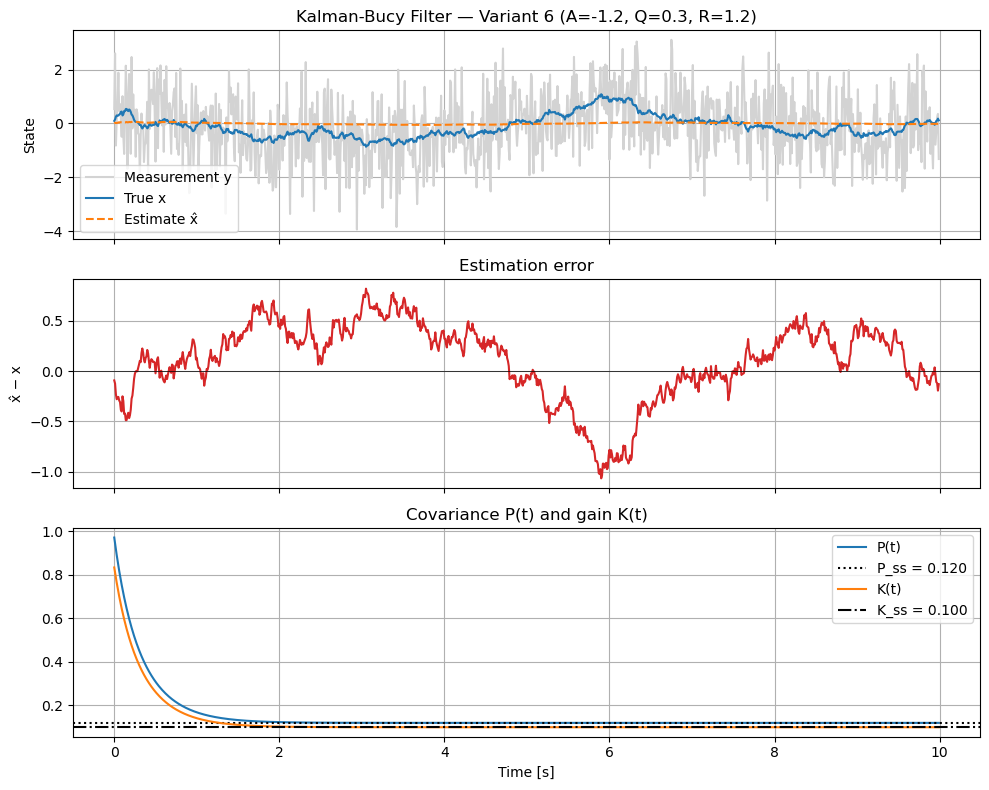

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

dt = 0.01
T = 10
N = int(T / dt)

# Variant 6
A = -1.2
C = 1.0
Q = 0.3
R = 1.2

P = 1.0
x_true = 0.0
x_hat = 0.0

t_hist = np.arange(N) * dt
x_hist = np.zeros(N)
xhat_hist = np.zeros(N)
y_hist = np.zeros(N)
P_hist = np.zeros(N)
K_hist = np.zeros(N)

for k in range(N):
    # True system (Euler–Maruyama)
    w = np.random.normal(0, np.sqrt(Q * dt))
    x_true += dt * (A * x_true) + w
    v = np.random.normal(0, np.sqrt(R))
    y = C * x_true + v

    # Kalman-Bucy update
    K = P * C / R
    x_hat += dt * (A * x_hat + K * (y - C * x_hat))
    P += dt * (2 * A * P + Q - K * C * P)

    x_hist[k] = x_true
    xhat_hist[k] = x_hat
    y_hist[k] = y
    P_hist[k] = P
    K_hist[k] = K

# Steady-state analytical solution of the ARE: 2AP + Q - P^2/R = 0
# => P_ss = AR + sqrt((AR)^2 + QR) (positive root)
P_ss = A * R + np.sqrt((A * R) ** 2 + Q * R)
K_ss = P_ss * C / R
print(f"Steady-state P = {P_ss:.4f}, K = {K_ss:.4f}")
print(f"Numerical    P(T) = {P_hist[-1]:.4f}, K(T) = {K_hist[-1]:.4f}")

err = xhat_hist - x_hist
rmse = np.sqrt(np.mean(err ** 2))
print(f"Estimation RMSE = {rmse:.4f}")

fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
ax[0].plot(t_hist, y_hist, color='lightgray', label='Measurement y')
ax[0].plot(t_hist, x_hist, label='True x')
ax[0].plot(t_hist, xhat_hist, '--', label='Estimate x̂')
ax[0].set_ylabel('State'); ax[0].legend(); ax[0].grid(True)
ax[0].set_title('Kalman-Bucy Filter — Variant 6 (A=-1.2, Q=0.3, R=1.2)')

ax[1].plot(t_hist, err, color='tab:red')
ax[1].axhline(0, color='k', lw=0.5)
ax[1].set_ylabel('x̂ − x'); ax[1].grid(True); ax[1].set_title('Estimation error')

ax[2].plot(t_hist, P_hist, label='P(t)')
ax[2].axhline(P_ss, color='k', ls=':', label=f'P_ss = {P_ss:.3f}')
ax[2].plot(t_hist, K_hist, label='K(t)')
ax[2].axhline(K_ss, color='k', ls='-.', label=f'K_ss = {K_ss:.3f}')
ax[2].set_xlabel('Time [s]'); ax[2].legend(); ax[2].grid(True)
ax[2].set_title('Covariance P(t) and gain K(t)')

plt.tight_layout(); plt.show()

### Part B — Interpretation

- The true system is **stable** (`A = -1.2 < 0`), so without disturbance `x` would decay to zero; the process noise `w` keeps it bouncing around zero.
- Measurement noise is larger than process noise (`R = 1.2 > Q = 0.3`), so the optimal filter trusts its model more than each raw sample. This yields a **small Kalman gain** and visibly smoother `x̂` than the raw measurement `y`.
- Solving the algebraic Riccati equation $2AP + Q - P^2/R = 0$ gives $P_{ss} = AR + \sqrt{(AR)^2 + QR}$ and $K_{ss} = P_{ss}/R$. For Variant 6 this evaluates exactly to $P_{ss} = -1.44 + \sqrt{2.4336} = -1.44 + 1.56 = 0.12$ and $K_{ss} = 0.10$. The simulated `P(t)` and `K(t)` converge to these values within a fraction of a second, confirming a correct implementation.
- Estimation error stays centered around zero (unbiased) and its standard deviation matches $\sqrt{P_{ss}} \approx 0.346$, as expected for the optimal continuous-time linear filter.